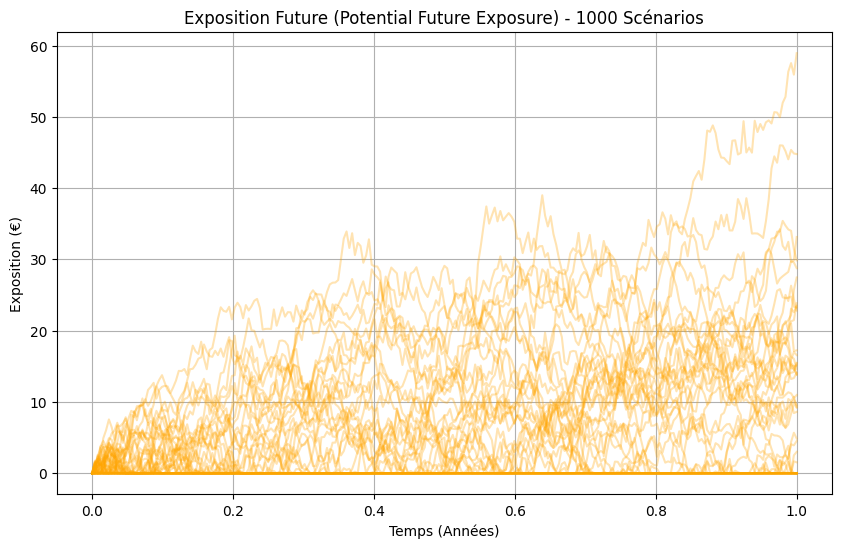

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Paramètres du Multivers ---
S0 = 100       # Prix initial
K = 100        # Strike du contrat
T = 1.0        # Maturité (1 an)
r = 0.05       # Taux sans risque
sigma = 0.2    # Volatilité
n_steps = 252  # Jours de trading
n_sims = 1000  # Nombre de simulations (Univers parallèles)

# Axe temps
dt = T / n_steps
t = np.linspace(0, T, n_steps + 1)

# --- 2. Moteur Monte Carlo Vectorisé ---
# On crée une matrice vide : 1000 lignes (scénarios) x 253 colonnes (jours)
S = np.zeros((n_sims, n_steps + 1))

S[:, 0] = S0

# Boucle sur le TEMPS uniquement (pas sur les simulations)
for i in range(1, n_steps + 1):
    # On génère 1000 chocs aléatoires d'un coup
    Z = np.random.normal(0, 1, n_sims)
    
    # Formule GBM appliquée à toute la colonne (vecteur)
    drift = (r - 0.5 * sigma**2) * dt
    shock = sigma * np.sqrt(dt) * Z
    
    # Mise à jour des 1000 prix pour le jour i
    S[:, i] = S[:, i-1] * np.exp(drift + shock)

# --- 3. Calcul de l'Exposition (Le Cœur du PFE) ---
# Valeur de marché du contrat (Mark-to-Market)
MtM = S - K 

# Exposition : On ne garde que les valeurs positives (Risque de Crédit)
# Si MtM < 0, l'exposition est 0.
E = np.maximum(MtM, 0)

# --- 4. Visualisation ---
plt.figure(figsize=(10, 6))

# On affiche les 50 premières trajectoires d'exposition pour voir "le spaghetti"
# .T transpose la matrice pour que l'axe X soit bien le temps
plt.plot(t, E[:50, :].T, alpha=0.3, color='orange')

plt.title(f"Exposition Future (Potential Future Exposure) - {n_sims} Scénarios")
plt.xlabel("Temps (Années)")
plt.ylabel("Exposition (€)")
plt.grid(True)
plt.show()